# EfficientNet-B0 Training - Separated Experiments
Each preprocessing version runs in a separate cell to avoid crashes:
- **Experiment 1**: Raw
- **Experiment 2**: Unified
- **Experiment 3**: Customized

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os, json, gc, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
from itertools import cycle

# SETUP
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = os.path.join("..", "data")
MODEL_DIR = "."
VIZ_DIR = os.path.join(MODEL_DIR, "visualizations", "efficientnet")
JSON_PATH = os.path.join(DATA_DIR, "dataset_split.json")
CATEGORIES = ['Can', 'Paper', 'Plastic Bag', 'Plastic Bottle']

# Create visualization directory
os.makedirs(VIZ_DIR, exist_ok=True)

print(f"Using device: {DEVICE}")
print(f"Visualization directory: {VIZ_DIR}")

# Load dataset split once
with open(JSON_PATH, 'r') as f: 
    split = json.load(f)
    
print(f"Train samples: {len(split['train'])}")
print(f"Test samples: {len(split['test'])}")

Using device: cuda
Visualization directory: .\visualizations\efficientnet
Train samples: 6319
Test samples: 1358


In [3]:
class WasteJSONDataset(Dataset):
    def __init__(self, root_dir, file_list, transform=None):
        self.root_dir, self.file_list, self.transform = root_dir, file_list, transform
        self.class_to_idx = {cat: i for i, cat in enumerate(CATEGORIES)}
        
    def __len__(self): return len(self.file_list)
        
    def __getitem__(self, idx):
        rel_path = self.file_list[idx]
        path = os.path.join(self.root_dir, rel_path)
        try:
            img = Image.open(path).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224), (0, 0, 0))
        label = self.class_to_idx[rel_path.split('/')[0]]
        if self.transform: img = self.transform(img)
        return img, label

def train_model_with_history(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    """Trains the model and returns loss/accuracy history for Learning Curves"""
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for imgs, lbls in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]'):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == lbls).sum().item()
            train_total += lbls.size(0)
            
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]'):
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                outputs = model(imgs)
                loss = criterion(outputs, lbls)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == lbls).sum().item()
                val_total += lbls.size(0)

        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(train_correct / train_total)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(val_correct / val_total)
        print(f"Epoch {epoch+1}: Train Acc: {history['train_acc'][-1]:.4f}, Val Acc: {history['val_acc'][-1]:.4f}")
    
    return model, history

In [4]:
def plot_learning_curves(history, version, save_path):
    """Plots Train/Val Loss and Accuracy over epochs"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss Plot
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    ax1.set_title(f'Learning Curve: Loss ({version.upper()})')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)
    
    # Accuracy Plot
    ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    ax2.plot(epochs, history['val_acc'], 'r-', label='Val Acc')
    ax2.set_title(f'Learning Curve: Accuracy ({version.upper()})')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
    
    plt.tight_layout(); plt.savefig(save_path, dpi=300); plt.show()

def plot_confusion_matrix(y_true, y_pred, version, save_path):
    """Plots the heatmap confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
    plt.title(f'Confusion Matrix - {version.upper()}', fontweight='bold')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout(); plt.savefig(save_path, dpi=300); plt.show()

def plot_pr_curves_cnn(y_true, y_probs, version, save_path):
    """Plots PR Curves to satisfy comprehensive visualization requirements"""
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])
    plt.figure(figsize=(10, 7))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red'])
    for i, color in zip(range(4), colors):
        p, r, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
        ap = average_precision_score(y_true_bin[:, i], y_probs[:, i])
        plt.plot(r, p, color=color, label=f'{CATEGORIES[i]} (AP = {ap:.2f})')
    plt.title(f'PR Curves - {version.upper()}'); plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.legend(); plt.grid(True, alpha=0.3); plt.savefig(save_path, dpi=300); plt.show()

In [8]:
def run_efficientnet_experiment(version, root_path):
    print(f"\n{'='*60}\n🚀 EfficientNet_B0 Experiment: {version.upper()}\n{'='*60}")
    if not os.path.exists(root_path): return None
    
    transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
                                   transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
    train_ds = WasteJSONDataset(root_path, split['train'], transform)
    val_ds = WasteJSONDataset(root_path, split['test'], transform)
    
    # Using batch_size=16 for memory stability on 6GB GPU
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0)
    
    # Model Setup
    model = models.efficientnet_b0(weights='IMAGENET1K_V1')
    
    # Access in_features from the existing linear layer in the classifier
    num_ftrs = model.classifier[1].in_features 
    model.classifier[1] = nn.Linear(num_ftrs, 4) 
    
    model = model.to(DEVICE)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    
    # 1. Train
    start_t = time.time()
    trained_model, history = train_model_with_history(model, train_loader, val_loader, criterion, optimizer, num_epochs=5)
    train_time = time.time() - start_t
    
    # 2. Evaluate
    all_preds, all_labels, all_probs = [], [], []
    trained_model.eval()
    start_inf = time.time()
    with torch.no_grad():
        for imgs, lbls in val_loader:
            outputs = trained_model(imgs.to(DEVICE))
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.numpy())
            all_probs.extend(probs.cpu().numpy())
    inf_time = (time.time() - start_inf) / len(all_labels)
    
    # 3. Visuals
    plot_learning_curves(history, version, os.path.join(VIZ_DIR, f"learning_{version}.png"))
    plot_confusion_matrix(all_labels, all_preds, version, os.path.join(VIZ_DIR, f"cm_{version}.png"))
    plot_pr_curves_cnn(all_labels, np.array(all_probs), version, os.path.join(VIZ_DIR, f"pr_{version}.png"))
    
    torch.save(trained_model.state_dict(), f"efficientnet_{version}.pth")
    return {
        'Model': 'EfficientNet', 'Preprocessing': version,
        'Accuracy': accuracy_score(all_labels, all_preds),
        'Precision': precision_score(all_labels, all_preds, average='macro', zero_division=0),
        'Recall': recall_score(all_labels, all_preds, average='macro', zero_division=0),
        'F1-score': f1_score(all_labels, all_preds, average='macro', zero_division=0),
        'Training_Time': train_time, 'Inference_Time': inf_time
    }


🚀 EfficientNet_B0 Experiment: RAW


Epoch 1/5 [Val]: 100%|██████████| 85/85 [00:18<00:00,  4.56it/s]


Epoch 1: Train Acc: 0.8865, Val Acc: 0.9705


Epoch 2/5 [Val]: 100%|██████████| 85/85 [00:14<00:00,  5.92it/s]


Epoch 2: Train Acc: 0.9679, Val Acc: 0.9786


...

Epoch 3: Train Acc: 0.9809, Val Acc: 0.9786


Epoch 4/5 [Val]: 100%|██████████| 85/85 [00:18<00:00,  4.59it/s]


Epoch 4: Train Acc: 0.9869, Val Acc: 0.9779


Epoch 5/5 [Val]: 100%|██████████| 85/85 [00:09<00:00,  8.99it/s]


Epoch 5: Train Acc: 0.9897, Val Acc: 0.9823


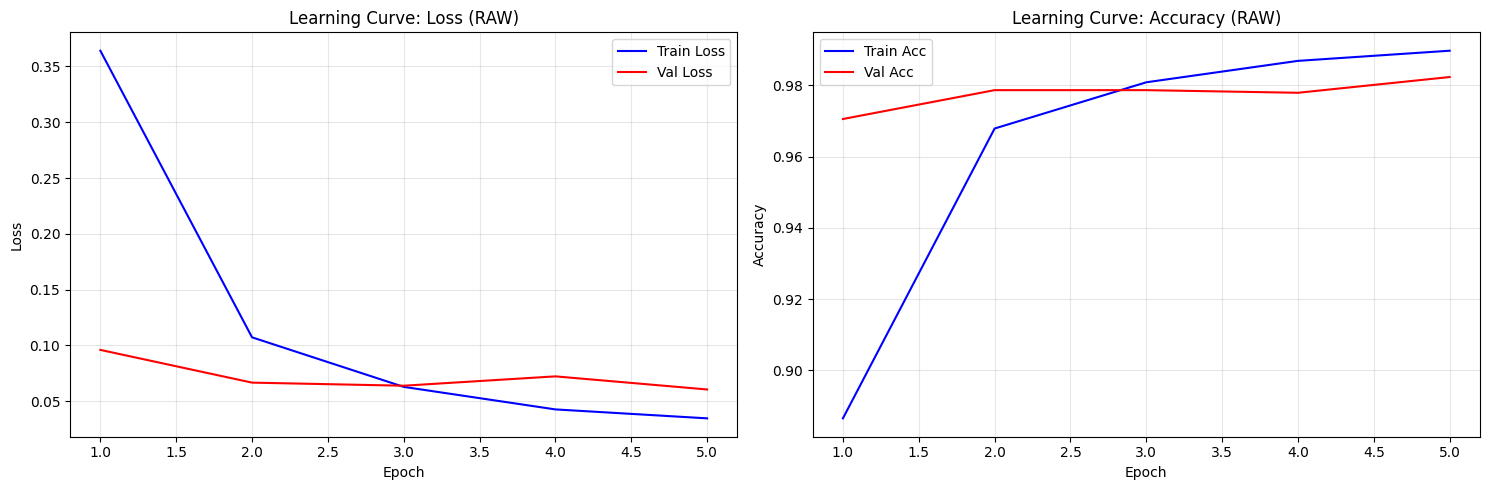

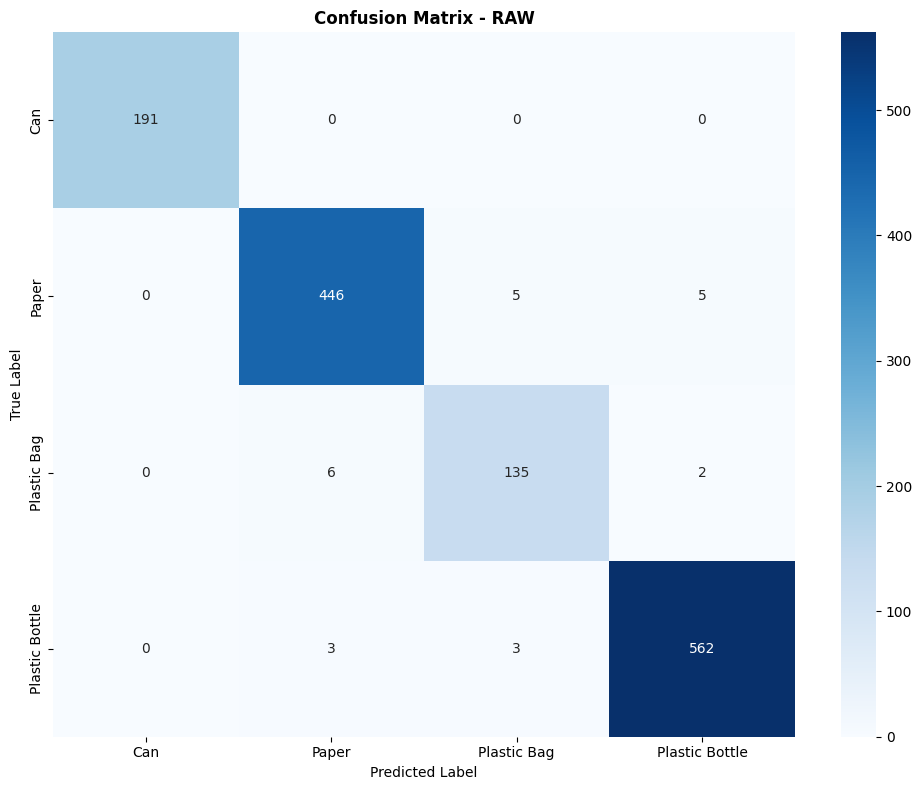

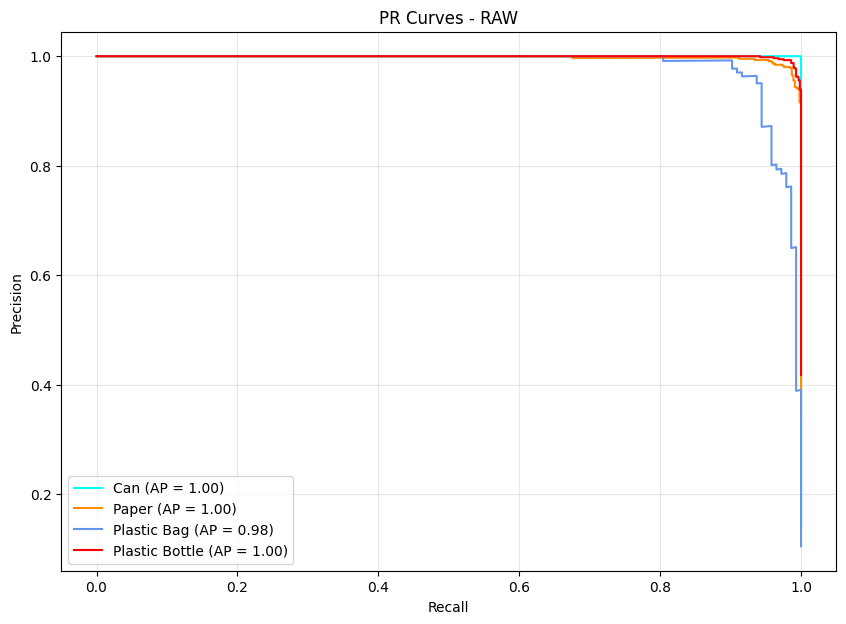

In [9]:
# 🔥 EXPERIMENT 1: RAW
torch.cuda.empty_cache(); gc.collect()
res_raw = run_efficientnet_experiment('raw', os.path.join(DATA_DIR, "Cropped"))


🚀 EfficientNet_B0 Experiment: UNIFIED


Epoch 1/5 [Val]: 100%|██████████| 85/85 [00:13<00:00,  6.14it/s]


Epoch 1: Train Acc: 0.7614, Val Acc: 0.8807


Epoch 2/5 [Val]: 100%|██████████| 85/85 [00:10<00:00,  8.38it/s]


Epoch 2: Train Acc: 0.8906, Val Acc: 0.9168


...

Epoch 3: Train Acc: 0.9329, Val Acc: 0.9197


Epoch 4/5 [Val]: 100%|██████████| 85/85 [00:12<00:00,  6.72it/s]


Epoch 4: Train Acc: 0.9560, Val Acc: 0.9300


Epoch 5/5 [Val]: 100%|██████████| 85/85 [00:15<00:00,  5.64it/s]


Epoch 5: Train Acc: 0.9690, Val Acc: 0.9212


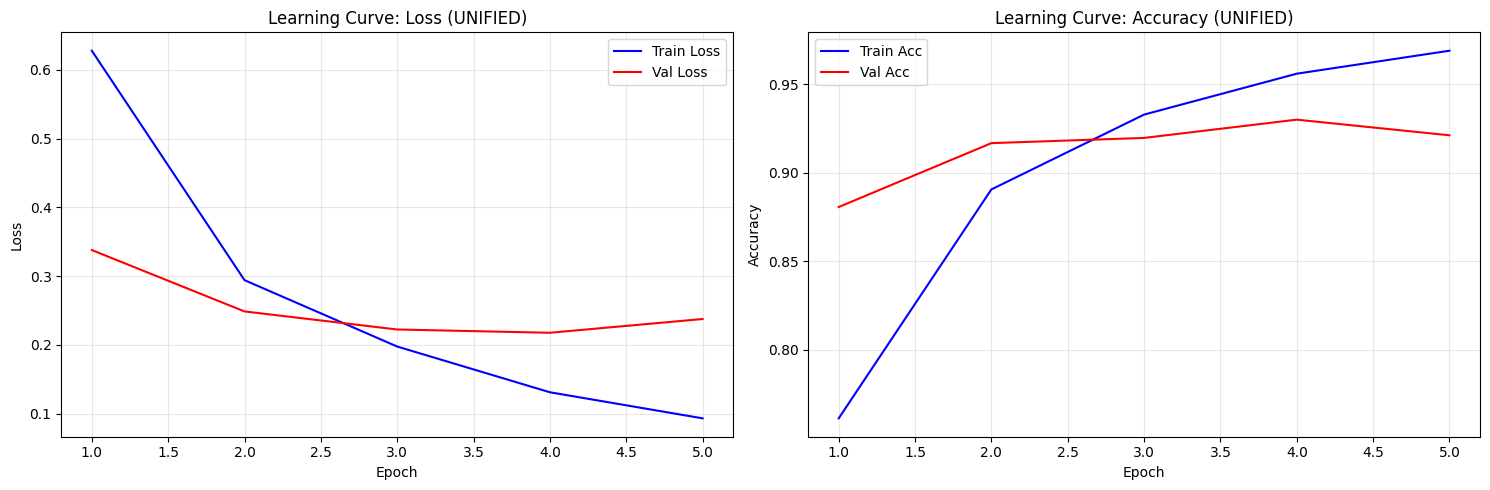

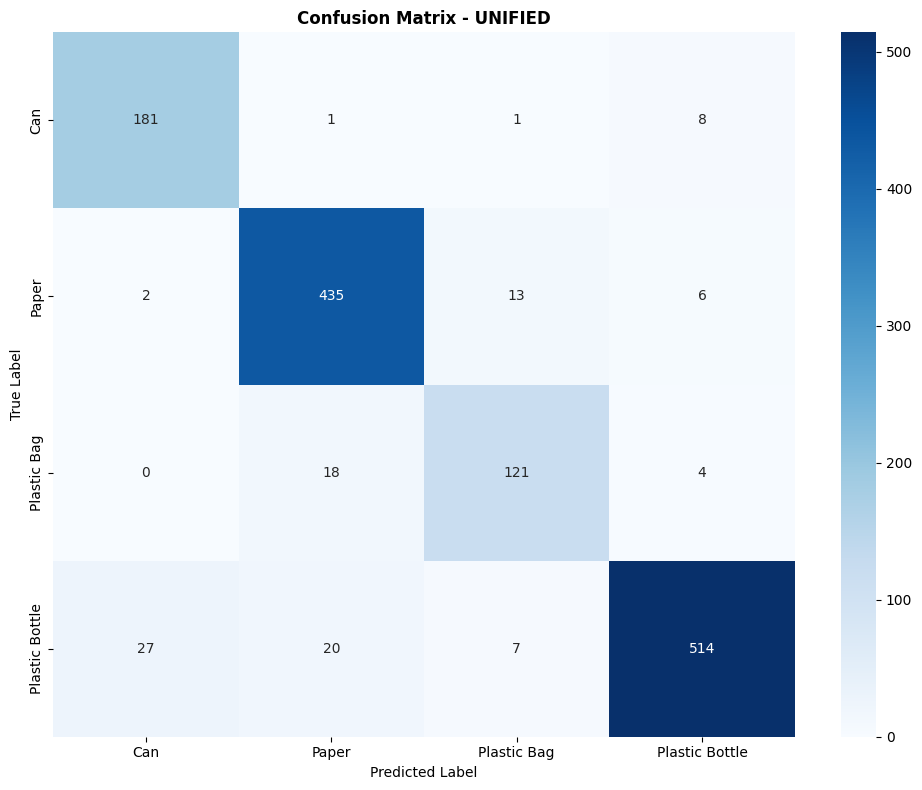

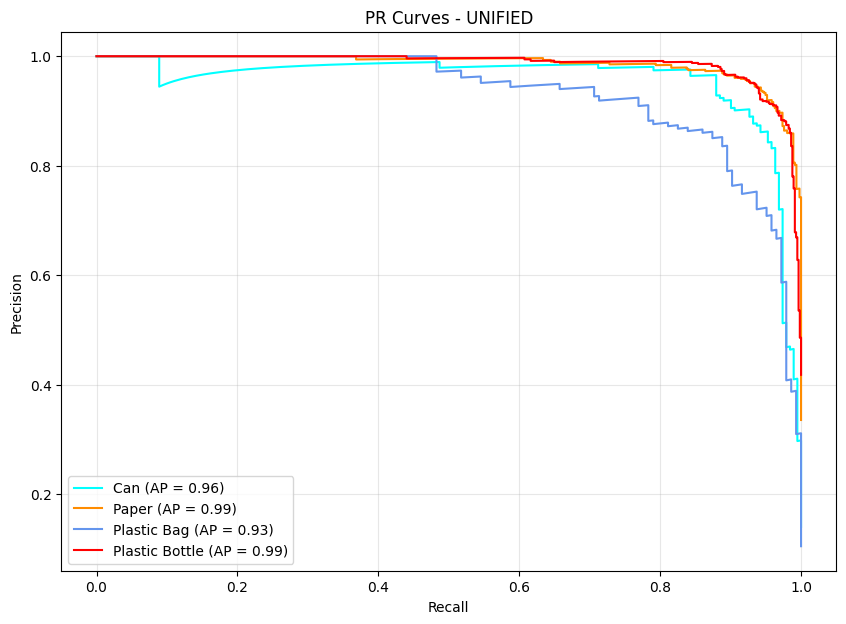

In [10]:
# 🔥 EXPERIMENT 2: UNIFIED
torch.cuda.empty_cache(); gc.collect()
res_unified = run_efficientnet_experiment('unified', os.path.join(DATA_DIR, "processed_unified"))


🚀 EfficientNet_B0 Experiment: CUSTOMIZED


Epoch 1/5 [Val]: 100%|██████████| 85/85 [00:11<00:00,  7.41it/s]


Epoch 1: Train Acc: 0.8937, Val Acc: 0.9639


Epoch 2/5 [Val]: 100%|██████████| 85/85 [00:09<00:00,  8.62it/s]


Epoch 2: Train Acc: 0.9600, Val Acc: 0.9742


...

Epoch 3: Train Acc: 0.9723, Val Acc: 0.9750


Epoch 4/5 [Val]: 100%|██████████| 85/85 [00:09<00:00,  8.94it/s]


Epoch 4: Train Acc: 0.9809, Val Acc: 0.9757


Epoch 5/5 [Val]: 100%|██████████| 85/85 [00:09<00:00,  8.82it/s]


Epoch 5: Train Acc: 0.9869, Val Acc: 0.9764


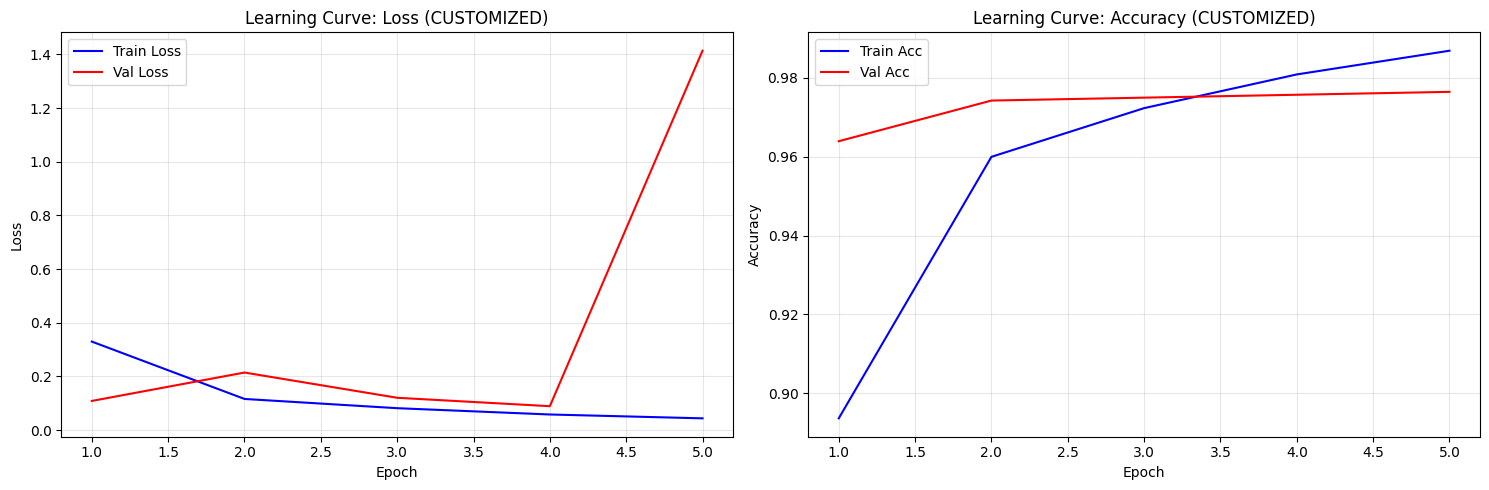

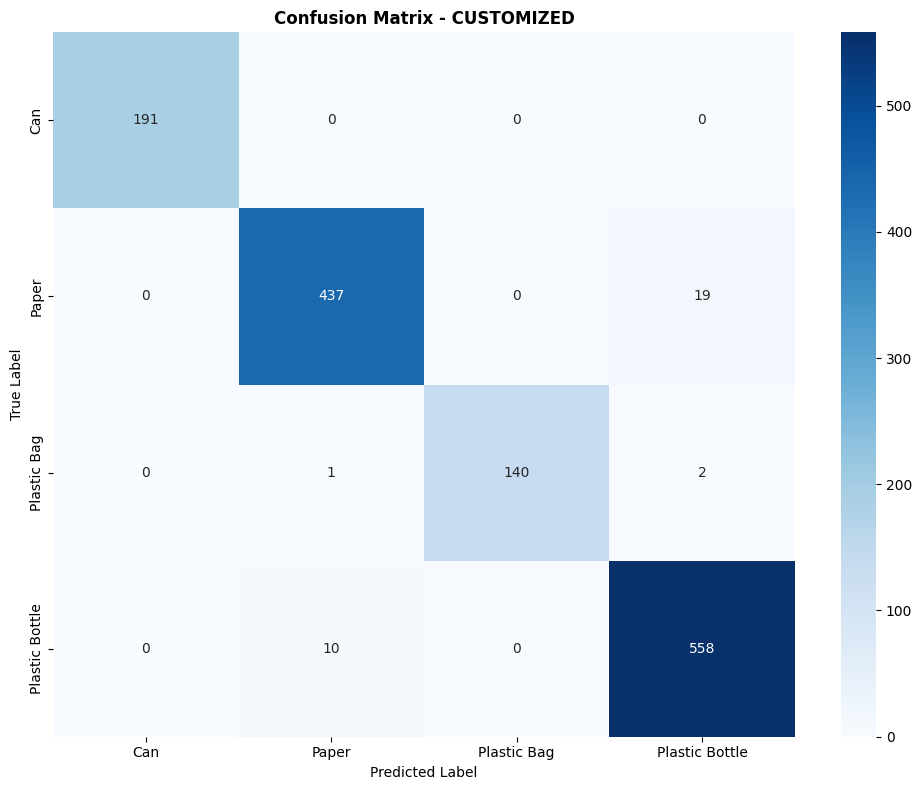

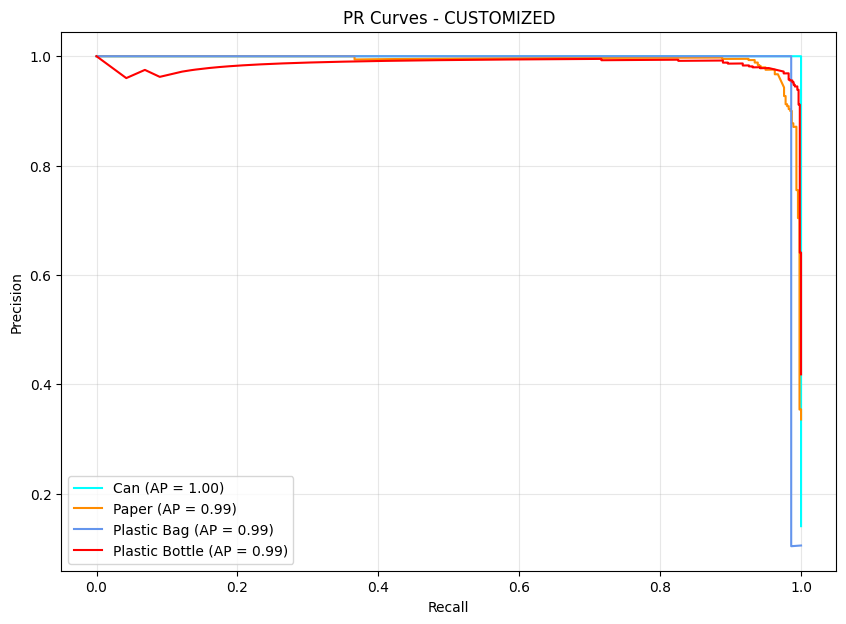

In [11]:
# 🔥 EXPERIMENT 3: CUSTOMIZED
torch.cuda.empty_cache(); gc.collect()
res_customized = run_efficientnet_experiment('customized', os.path.join(DATA_DIR, "processed_customized"))


📊 FINAL SUMMARY:
       Model Preprocessing  Accuracy  Precision   Recall  F1-score  Training_Time  Inference_Time
EfficientNet           raw  0.982327   0.977993 0.977891  0.977942     579.738383        0.008716
EfficientNet       unified  0.921208   0.899476 0.913169  0.905474     496.404003        0.010006
EfficientNet    customized  0.976436   0.984794 0.979937  0.982297     359.793077        0.007467


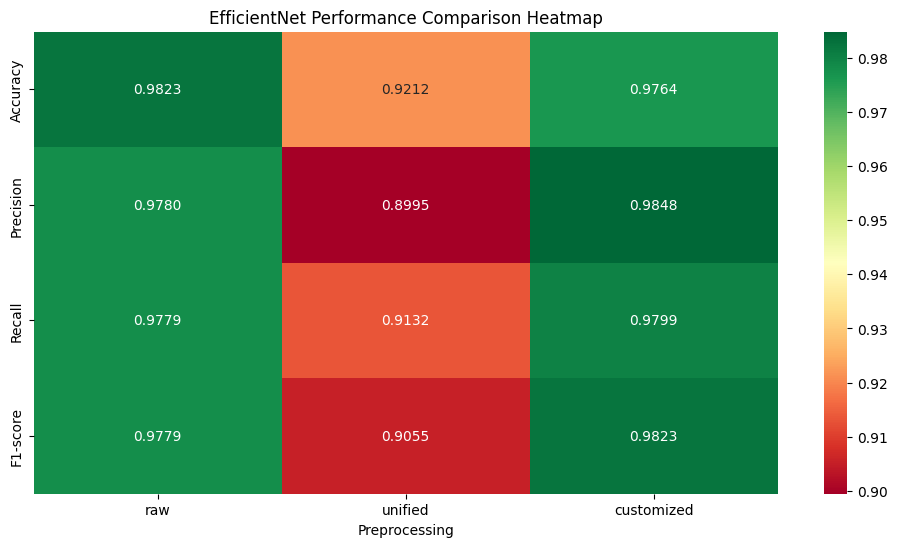


🏁 EfficientNet experiments with full visualization completed!


In [12]:
all_results = [r for r in [res_raw, res_unified, res_customized] if r is not None]

if all_results:
    df = pd.DataFrame(all_results)
    df.to_csv(os.path.join(DATA_DIR, "efficientnet_all_results.csv"), index=False)
    print(f"\n📊 FINAL SUMMARY:\n{'='*60}\n{df.to_string(index=False)}")
    
    plt.figure(figsize=(12, 6))
    sns.heatmap(df[['Preprocessing', 'Accuracy', 'Precision', 'Recall', 'F1-score']].set_index('Preprocessing').T, 
                annot=True, fmt='.4f', cmap='RdYlGn')
    plt.title('EfficientNet Performance Comparison Heatmap')
    plt.savefig(os.path.join(VIZ_DIR, "final_comparison.png"))
    plt.show()

print("\n🏁 EfficientNet experiments with full visualization completed!")